## This is to display the final version of the model

1. Define the mappings from the neuron index to the spatial space.

\begin{equation}
    \theta_k := - \frac\pi2 + \frac{k-k_1}{k_2-k_1}\pi \tag{1}
\end{equation}

2. Define the ideal solutions for the edge/bump attractor

\begin{equation}
U_{B,D}(\theta;\,\hat\theta) = U_0 \exp\left[-\frac{(\theta-\hat\theta)^2}{4a^2}\right] \tag{2}
\end{equation}

\begin{equation}
U_{E,D}(\theta;\,\hat\theta) \;=\; 2 \exp\!\left[-e^{-s(\theta-\hat\theta)}\right]-1 \tag{3}
\end{equation}

For the edge solution, notice we could assume a symmteric kernel to construct the connectivity matrix instead, and the solution is:

\begin{equation}
\tilde{U}_{E,D}(\theta;\,\hat\theta) \;=\; \tanh\left[s'(\theta-\hat{\theta})\right]\tag{3}
\end{equation}
where $s'=\frac{2s}{e}$.


3. Map back to the index space:

\begin{align}
U_{B,D}[k;\hat k]
&= U_0 \exp\!\left[
-\frac{\pi^2}{4a^2\,(k_2-k_1)^2}\,(k-\hat k)^2
\right] \tag{4}\\[6pt]
U_{E,D}[k;\hat k]
&= 2\,\exp\!\left[
-\exp\!\left(
-\;s\,\frac{\pi}{\,k_2-k_1\,}\,(k-\hat k)
\right)\right]-1 \tag{5}
\end{align}
or
\begin{equation}
\tilde{U}_{E,D}[k;\hat k] = \tanh\left[s' \frac{\pi}{k_2-k_1}(k-\hat k)\right]
\tag{6}
\end{equation}

Below we show that the network is caplable of reproducing the dynamics provided by eq 4. and eq 5.



In [1]:
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model import CANN_DDM_model
from tqdm import tqdm
import pickle
import seaborn as sns

/projectnb/ecog-eeg/cyw6/.conda/envs/cann_ddm_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 1, 'c_EB': 5,
             'beta_E': 2.5, 'sigma_E': 2, 
            'fixed_ratio': 0.05, 'J0_E': 2, 'edge_type': 'tanh', 
            'edge_offset': -0.006176,  's_E': 1.05,
            'direction': 'left',
            'k1': int(0.3 * 1024), 'k2': int(0.5 * 1024),
            'K0': int(0.4 * 1024)}
#-0.006176
bump_pop = {'num_B': 1024, 'tau_B': .1, 'c_BE': 2.5,
            'c_BE_params': {'mode': 'const'}, 
            'boundary': 1, 'beta_B': 2.5, 'sigma_B': 1, 
              'J0_B': 10, 'k_B': 0.01, 'a_B': 1, 'm_B': 0, 'tau_VB': 10}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 0, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur1': 100, 'dur2': 1000, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)



In [3]:
#pos_offset = model.get_pos_offset(model.x0, model.s_E)
pos_offset = 0.03

In [4]:
decision_space_params.update({'seed': 2025})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)
runner, RT = model.run_simulation(mon_vars = ['U_B', 'U_E', 
            'r_E', 'r_B', 
            'x_B', 'x_E', 
            'I_BE', 'I_EB',
            'I_EE', 'I_BB',
            'theta_B', 'theta_E', 'hit_boundary'], pos_offset=pos_offset, get_RT=True)

Predict 1100 steps: : 100%|██████████| 1100/1100 [00:00<00:00, 1186.82it/s]


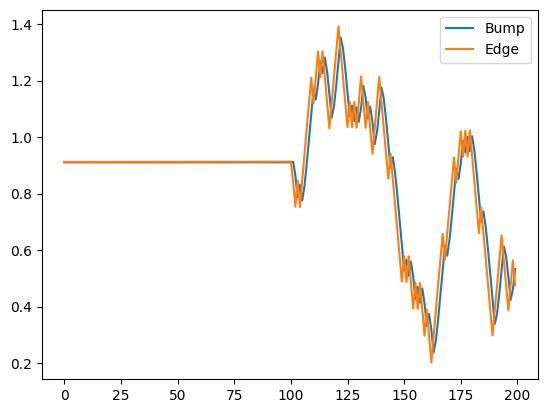

In [5]:
plt.plot(runner.mon.theta_B[100:300], label='Bump')
plt.plot(runner.mon.theta_E[100:300], label='Edge')
plt.legend()

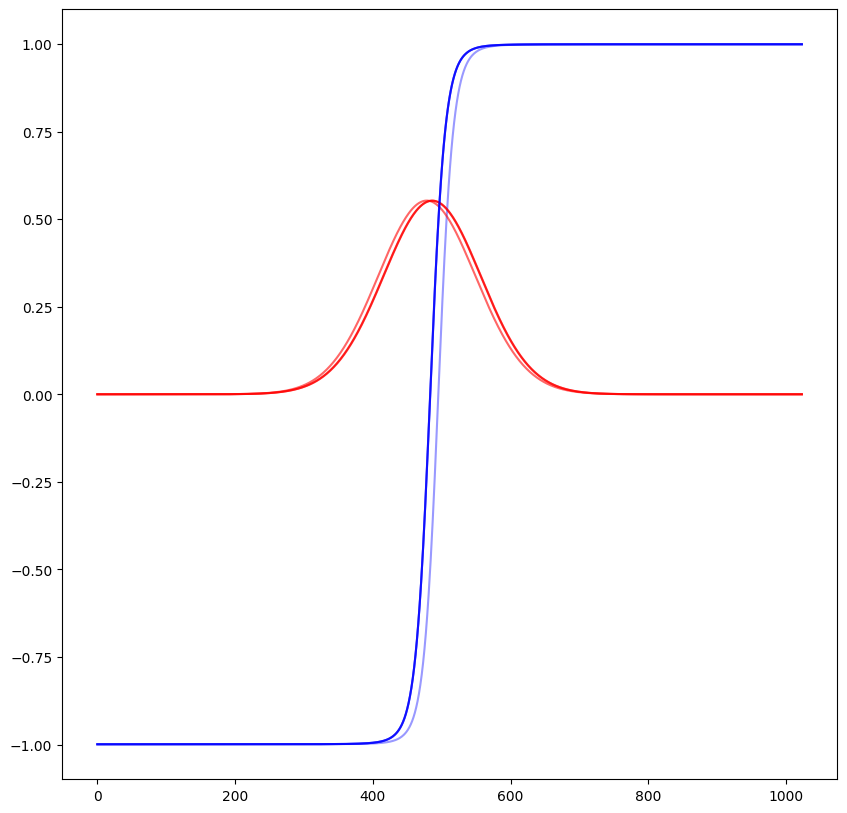

In [13]:
plt.figure(figsize=(10, 10))
t_min = 200
t_max = 250
for t in range(t_min, t_max, 10):
    plt.plot(runner.mon.r_B[t, :], color='red', alpha= (t-t_min)/(t_max-t_min))
    plt.plot(runner.mon.r_E[t, :], color='blue', alpha= (t-t_min)/(t_max-t_min))
    #plt.plot(runner.mon.I_EB[t,:], 'black', alpha= (t-t_min)/(t_max-t_min))
    #plt.plot(runner.mon.I_BE[t,:], 'green', alpha = (t-t_min)/(t_max-t_min))
    #plt.plot(runner.mon.r_E[i, :], color='blue')
    
plt.show()

## Fig 1

 Now we need to determine a coupling strength function $c_{BE}(\theta)$ which makes the strength of the input from bump to edge only dependent on the current phase of the attractor such that the effective displacement 

\begin{equation} \Delta\theta_{\text{eff}}\!\big(c_{BE}(\theta);\theta\big)\approx\Delta\theta_{\text{req}}(\theta)=\frac{1}{s}\,\left|\log\!\Big(1 \pm \tfrac{\ell}{\phi(\theta)}\Big)\right|,
\notag
 \end{equation}

Then we can derive the coupling function:
\begin{equation} c_{BE}(\theta)=\Delta\theta_{\text{eff}}^{-1}\!\big(\Delta\theta_{\text{req}}(\theta);\theta\big). 
\notag
 \end{equation}


In [ ]:
dtheta_B = {}
c_BE_vals = np.array([0.1] + list(np.linspace(0.25, 3, 12)))
#c_BE_vals = [2.5]
runners= {}
for c_BE in tqdm(c_BE_vals):
    dtheta_B[c_BE] = []
    runners[c_BE] = []
    bump_pop.update({'c_BE': c_BE})
    CANN_params.update({'bump_pop': bump_pop})
    for i in range(10):
        decision_space_params.update({'seed': 2025+i, 'drift_rate': 0})
        CANN_params.update({'decision_space_params': decision_space_params})
        model = CANN_DDM_model(CANN_params = CANN_params)
        mon_vars = ['theta_B', 'theta_E', 'hit_boundary']
        runner, RT = model.run_simulation(mon_vars = mon_vars, progress_bar=False, pos_offset = pos_offset, get_RT=True)
        t_start = int(model.t_start)
        if RT:
            t_end = int(t_start + RT)
        else:
            t_end = -1
        runners[c_BE].append(runner)
        dtheta_B[c_BE].append(np.mean(np.abs(np.diff(runner.mon.theta_E[t_start:t_end, 0]))))
plt.show()

with open('results/dtheta_B_tanh_edge.pkl', 'wb') as f:
    pickle.dump(dtheta_B, f)

In [4]:
# read dtheta_B.pkl
with open('results/dtheta_B_tanh_edge.pkl', 'rb') as f:
    dtheta_B = pickle.load(f)



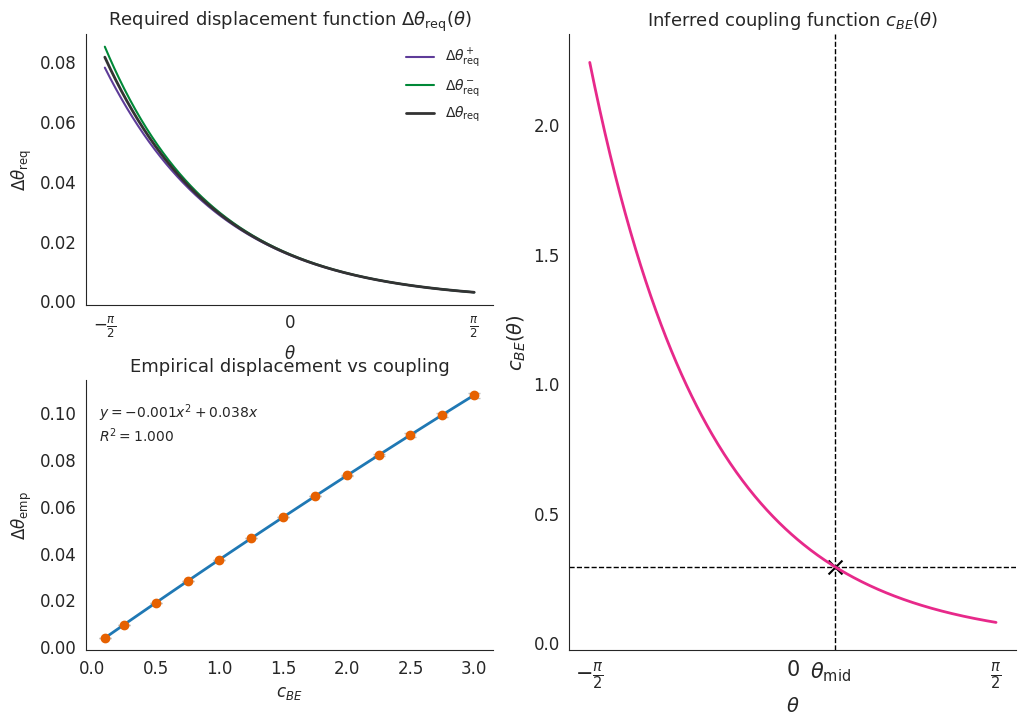

In [ ]:
# Top-left: required displacement; bottom-left: empirical displacement vs coupling; right: inferred c_BE(theta)
sns.set_style('white')
plt.rcParams.update({'font.size':12, 'font.family':'sans-serif'})

# --- required displacement curves ---
theta_req_pos = lambda theta: 1/(model.s_E*model.dt_DDM) * bm.log(1 + model.dx / model.pos_to_evidence(theta, model.s_E))
theta_req_neg = lambda theta: -1/(model.s_E*model.dt_DDM) * bm.log(1 - model.dx / model.pos_to_evidence(theta, model.s_E))
theta_req = lambda theta: 0.5 * (theta_req_pos(theta) + theta_req_neg(theta))
#x_req = lambda theta: model.pos_to_evidence(theta+theta_req(theta), model.s_E) - model.pos_to_evidence(theta, model.s_E)

theta_vals = np.linspace(-np.pi/2, np.pi/2, 400)
req_pos = theta_req_pos(theta_vals)
req_neg = theta_req_neg(theta_vals)
req_mid = theta_req(theta_vals)

# --- empirical data and quadratic fit through origin (from dtheta_B) ---
c_BE_keys = np.array(list(dtheta_B.keys()))
means = np.array([np.mean(dtheta_B[c_BE]) for c_BE in c_BE_keys])
stds = np.array([np.std(dtheta_B[c_BE]) for c_BE in c_BE_keys])
order = np.argsort(c_BE_keys)
x_s = c_BE_keys[order]
y_s = means[order]
y_err = stds[order]

# Fit quadratic function through origin: y = ax^2 + bx (no constant term)
# Use least squares to solve: y = a*x^2 + b*x
A = np.column_stack([x_s**2, x_s])
coeffs = np.linalg.lstsq(A, y_s, rcond=None)[0]
a_quad, b_quad = coeffs[0], coeffs[1]

# Invert quadratic fit to compute c_BE(theta): solve a*c^2 + b*c - Delta_req = 0
c_BE_theta = model.c_BE_theta(c_BE_params={'mode': 'quadratic', 'a': a_quad, 'b': b_quad})

# tested range and clipping for display
tested_min, tested_max = x_s.min(), x_s.max()

# --- figure layout: left column two rows, right column full height ---
from matplotlib import gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.1], height_ratios=[1, 1], hspace=0.28, wspace=0.18)
ax_req = fig.add_subplot(gs[0, 0])   # top-left
ax_emp = fig.add_subplot(gs[1, 0])   # bottom-left
ax_cbe = fig.add_subplot(gs[:, 1])   # right (span)

# Set theta axis ticks
theta_ticks = [-np.pi/2, 0, np.pi/2]
theta_ticklabels = [r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$']

# Top-left: required displacement
ax_req.plot(theta_vals, req_pos, color='#5e3c99', lw=1.5, label=r'$\Delta\theta_{\mathrm{req}}^+$')
ax_req.plot(theta_vals, req_neg, color='#008837', lw=1.5, label=r'$\Delta\theta_{\mathrm{req}}^-$')
ax_req.plot(theta_vals, req_mid, color='#333333', lw=2.0, label=r'$\Delta\theta_{\mathrm{req}}$')
ax_req.set_xlabel(r'$\theta$', fontsize=12)
ax_req.set_ylabel(r'$\Delta\theta_{\mathrm{req}}$', fontsize=12)
ax_req.set_title(r'Required displacement function $\Delta\theta_{\mathrm{req}}(\theta)$', fontsize=13)
ax_req.legend(loc='upper right', frameon=False, fontsize=10)
ax_req.spines['top'].set_visible(False)
ax_req.spines['right'].set_visible(False)
ax_req.tick_params(direction='out')
ax_req.set_xticks(theta_ticks)
ax_req.set_xticklabels(theta_ticklabels, fontsize=12)

# Bottom-left: empirical displacement vs coupling
ax_emp.errorbar(x_s, y_s, yerr=y_err, fmt='o',
                color='#e66101', ecolor='#bdbdbd', capsize=4, markersize=6)
# Plot quadratic fit curve
x_fit = np.linspace(x_s.min(), x_s.max(), 100)
y_fit = a_quad * x_fit**2 + b_quad * x_fit
ax_emp.plot(x_fit, y_fit, color='#1f78b4', linestyle='-', lw=2)
ax_emp.set_xlabel(r'$c_{BE}$', fontsize=12)
ax_emp.set_ylabel(r'$\Delta\theta_{\text{emp}}$', fontsize=12)
ax_emp.set_title('Empirical displacement vs coupling', fontsize=13)
# Calculate R²
y_pred = a_quad * x_s**2 + b_quad * x_s
r_squared = 1 - np.sum((y_s - y_pred)**2) / np.sum((y_s - np.mean(y_s))**2) if np.sum((y_s - np.mean(y_s))**2) != 0 else np.nan
ax_emp.text(0.03, 0.92, f'$y={a_quad:.3f}x^2+{b_quad:.3f}x$\n$R^2={r_squared:.3f}$',
            transform=ax_emp.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=10)
ax_emp.spines['top'].set_visible(False)
ax_emp.spines['right'].set_visible(False)
ax_emp.tick_params(direction='out')

# Right: inferred c_BE(theta)
theta_mid = model.pos_to_evidence(0.5, model.s_E)
c_BE_mid = c_BE_theta(theta_mid)
ax_cbe.scatter(theta_mid, c_BE_mid, color='black', s=100, marker='x')
ax_cbe.axhline(y=c_BE_mid, color='black', linestyle='--', lw=1)
ax_cbe.axvline(x=theta_mid, color='black', linestyle='--', lw=1)
c_BE_vals = [c_BE_theta(theta) for theta in theta_vals]
ax_cbe.plot(theta_vals, c_BE_vals, color='#e7298a', lw=2)
ax_cbe.set_xlabel(r'$\theta$', fontsize=14)
ax_cbe.set_ylabel(r'$c_{BE}(\theta)$', fontsize=14)
ax_cbe.set_title(r'Inferred coupling function $c_{BE}(\theta)$', fontsize=13)
ax_cbe.spines['top'].set_visible(False)
ax_cbe.spines['right'].set_visible(False)
ax_cbe.tick_params(direction='out')

ax_cbe.set_xticks([-np.pi/2, 0, c_BE_mid, np.pi/2])
ax_cbe.set_xticklabels([r'$-\frac{\pi}{2}$', r'$0$', r'$\theta_{\text{mid}}$', r'$\frac{\pi}{2}$'], fontsize=15)

for ax in [ax_req, ax_emp, ax_cbe]:
    ax.grid(False)

plt.show()


## Fig 2

 Now we compare the simulated trajectories and the ground truth trajectories for two example trials. We first specify the rule for the coupling strength $c_{\text{BE}}$ to make it dependent on the the position of edge / bump attractor.


In [6]:
bump_pop.update({'c_BE_params': {'mode': 'quadratic', 'a': a_quad, 'b': b_quad}})
#bump_pop.update({'c_BE': 1})
CANN_params.update({'bump_pop': bump_pop})
decision_space_params.update({'seed': 2024, 'drift_rate': 1})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)

In [7]:


# drift_rate = 1
decision_space_params.update({'seed': 2024, 'drift_rate': 1})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)

mon_vars = ['theta_B', 'theta_E', 'hit_boundary', 'x_B', 'x_E', 'c_BE_dyn']
runner, RT = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)

t_start = 150
x_B_1 = runner.mon.x_B[t_start:, 0]
theta_B_1 = runner.mon.theta_B[t_start  :, 0]
x_E_1 = runner.mon.x_E[t_start:, 0]
theta_E_1 = runner.mon.theta_E[t_start:, 0]
x_traj_1 = model.x_traj[t_start:]
theta_traj_1 = model.evidence_to_pos(x_traj_1, model.s_E)

# drift_rate = -1
decision_space_params.update({'seed': 2025, 'drift_rate': -1})
CANN_params.update({'decision_space_params': decision_space_params})
model = CANN_DDM_model(CANN_params = CANN_params)
runner, RT = model.run_simulation(mon_vars = mon_vars, progress_bar=True, pos_offset = pos_offset, get_RT=True)
x_B_2 = runner.mon.x_B[t_start:, 0]
theta_B_2 = runner.mon.theta_B[t_start:, 0]
x_E_2 = runner.mon.x_E[t_start:, 0]
theta_E_2 = runner.mon.theta_E[t_start:, 0]
x_traj_2 = model.x_traj[t_start:]
theta_traj_2 = model.evidence_to_pos(x_traj_2, model.s_E)




Predict 1100 steps: : 100%|██████████| 1100/1100 [00:00<00:00, 1206.32it/s]


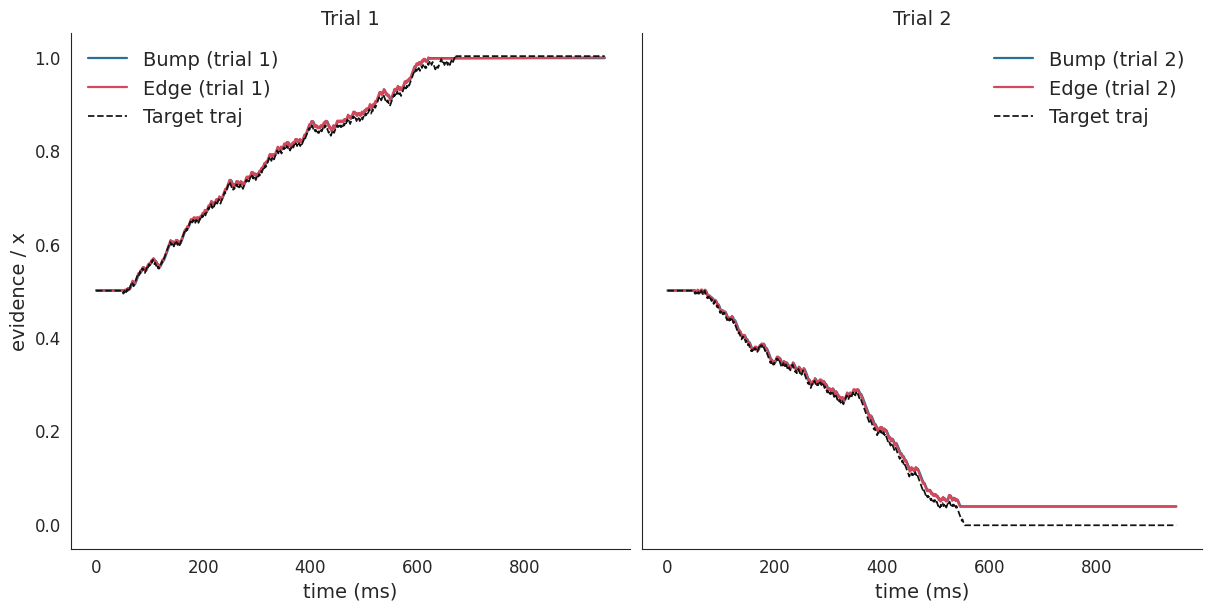

In [8]:
sns.set_style('white')

colors = {'bump':'#2A6F97', 'edge':'#D1495B', 'traj':'#111111'}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, constrained_layout=True)
ax1, ax2 = axes

# Trial 1
times1 = np.arange(len(x_B_1))
ax1.plot(times1, x_B_1, color=colors['bump'], lw=1.6, label='Bump (trial 1)')
ax1.plot(times1, x_E_1, color=colors['edge'], lw=1.6, label='Edge (trial 1)')
ax1.plot(times1, x_traj_1, color=colors['traj'], lw=1.25, linestyle='--', label='Target traj')
ax1.set_title('Trial 1', fontsize=14)
ax1.set_xlabel('time (ms)', fontsize=14)
ax1.set_ylabel('evidence / x', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(direction='out')
ax1.legend(frameon=False, fontsize=14)

# Trial 2
times2 = np.arange(len(x_B_2))
ax2.plot(times2, x_B_2, color=colors['bump'], lw=1.6, label='Bump (trial 2)')
ax2.plot(times2, x_E_2, color=colors['edge'], lw=1.6, label='Edge (trial 2)')
ax2.plot(times2, x_traj_2, color=colors['traj'], lw=1.25, linestyle='--', label='Target traj')
ax2.set_title('Trial 2', fontsize=14)
ax2.set_xlabel('time (ms)', fontsize=14)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(direction='out')
ax2.legend(frameon=False, fontsize=14)

plt.show()

6. We demonstrated that the edge neurons are ramping up with different speeds at different drift rates.

Predict 1100 steps: : 100%|██████████| 1100/1100 [00:00<00:00, 1281.30it/s]


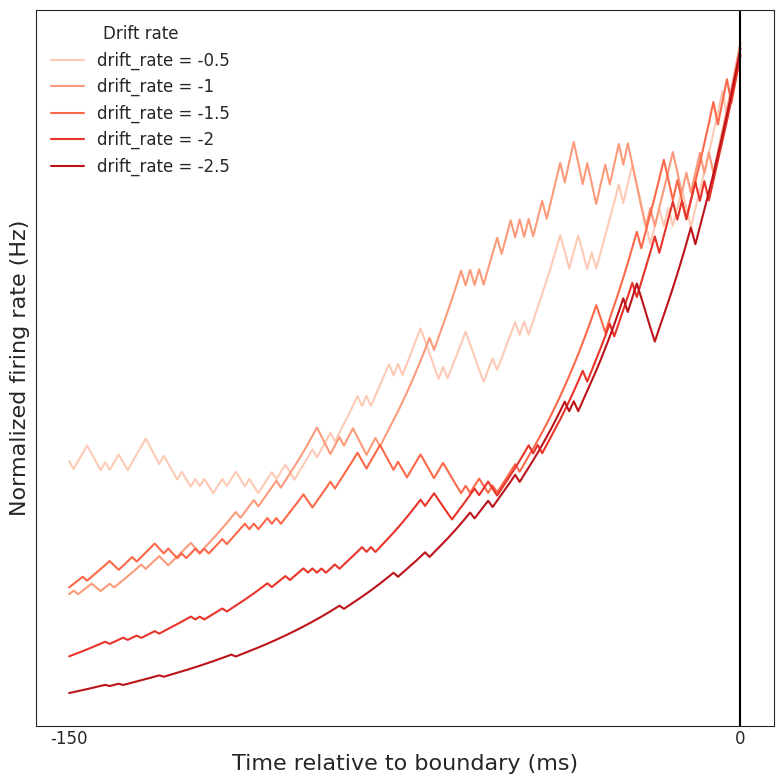

In [10]:
import numpy as np
import matplotlib.pyplot as plt

idx = 350  # example neuron index
t_start = 200
drift_rates = [-0.5, -1, -1.5, -2, -2.5]
cmap = plt.get_cmap('Reds')
colors = cmap(np.linspace(0.2, 0.8, len(drift_rates)))

plt.figure(figsize=(8, 8))
for rate, color in zip(drift_rates, colors):
    decision_space_params.update({'seed': 2025, 'drift_rate': rate})
    CANN_params.update({'decision_space_params': decision_space_params})
    model = CANN_DDM_model(CANN_params=CANN_params)
    mon_vars = ['x_E', 'r_E', 'U_E', 'hit_boundary']
    runner, RT = model.run_simulation(mon_vars=mon_vars, progress_bar=True, pos_offset=pos_offset, get_RT=True)
    start_idx = int(t_start + RT) - 150
    end_idx = int(t_start + RT)
    fr = runner.mon.U_E[start_idx:end_idx, idx]
    # x axis: time relative to boundary
    x = np.linspace(-150, 0, len(fr))
    plt.plot(x, fr, color=color, label=f'drift_rate = {rate}')

# vline at boundary (time 0)
plt.axvline(0, color='black', alpha=1)

# Ticks: only at start and boundary
ax = plt.gca()
ax.set_xticks([-150, 0])
ax.set_xticklabels(['-150', '0'], fontsize=12)
ax.set_yticks([])
ax.tick_params(axis='both', which='both', length=0)

# Labels and legend
ax.set_xlabel('Time relative to boundary (ms)', fontsize=16)
ax.set_ylabel('Normalized firing rate (Hz)', fontsize=16)
ax.legend(title='Drift rate', loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


